# ΔF/F vs deconvolved events — SLAP2, both colour channels

The SLAP2 counterpart of `dff_vs_events_mesoscope.ipynb`. Same question — what
does deconvolution change about a stimulus-locked response — run for both
sensors, since that is where SLAP2 differs most from the mesoscope:

* **Green is iGluSnFR4f**, a glutamate sensor that decays in tens of
  milliseconds. Its ΔF/F is already almost as sharp as an event train.
* **Red is RCaMP3**, a calcium sensor roughly five times slower, so its ΔF/F
  smears a response over several stimulus presentations — the regime where
  deconvolution earns its keep.

Two more things differ from the mesoscope:

* **The events are computed here.** The mesoscope NWB files ship an
  `event_timeseries`; the SLAP2 release (dandiset 001424) carries only `F0` and
  `dFF`. `utils.deconvolution` runs OASIS over the traces and caches the result
  per (session, DMD, channel); this notebook loads that cache, computing it on
  first use (~20 s per DMD and channel).
* **Imaging is not continuous.** SLAP2 records in ~30 s bouts with blanking in
  between and blanks further short stretches of samples to NaN. The
  deconvolution runs per contiguous segment for that reason, and trials that
  fall in a gap are dropped here rather than plotted across the hole.

**Stimulus.** Gabor patches on a 9 × 9 grid × 3 orientations, 0.25 s each with a
0.267 s interval, 5 repeats per (orientation, position). Imaging runs at ~200 Hz,
so one Gabor spans ~50 samples.

In [47]:
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

sys.path.append('..')
import utils
from utils.deconvolution import slap2_events_df, events_path

## Configuration

In [48]:
SESSION = 'sub-829704_ses-829704-2025-12-18-10-57-36_image+ophys'
NWB_PATH = Path('../../../rawdata/allen_open_scope/slap2/sub-829704') / f'{SESSION}.nwb'
GABOR_ROOT = Path('../../../results/allen_open_scope/rf/gabors')
STIM_TABLE = 'rf_mapping'

CHANNELS = ('green', 'red')   # iGluSnFR4f, RCaMP3
N_UNITS = 6                   # example ROIs per channel
PRE, POST = 0.3, 1.0          # seconds shown before / after the Gabor onset
# Trial averages are pooled into bins this wide. At ~5 ms sampling, 5 repeats of
# a sparse event train average to spikes and zeros, so the raw mean is not
# readable; binning also puts both DMDs on one grid despite their slightly
# different sampling rates (215 vs 201 Hz here).
BIN = 0.025
# Fewest imaged repeats (of 5) an ROI needs to enter the timing summary, where
# every curve is divided by its own peak.
MIN_TRIALS = 3
# ROIs entering the population timing panel. The permutation floor (1/1001 with
# 1000 shuffles) needs zero of 1000 shuffles to beat the observed statistic and
# only 9 green / 5 red ROIs reach it, so the panel uses a threshold instead.
P_MAX = 0.01

# ΔF/F is drawn in its own channel's colour, the deconvolved events in black.
CHANNEL_COLORS = {'green': '#008300', 'red': '#e34948'}
EVENTS_COLOR = '#000000'
REF_COLOR = '0.62'            # mean response to all other Gabors
STIM_COLOR = '0.88'           # Gabor on screen
GAP_COLOR = '#f2e3d5'         # blanking, i.e. not imaged

# ΔF/F results now live in a per-signal tree; runs from before that change sit
# directly under the session directory
SIEGLE_DIR = next(d for d in (GABOR_ROOT / 'dff' / SESSION, GABOR_ROOT / SESSION) if d.is_dir())
print(f'Siegle results: {SIEGLE_DIR}')

Siegle results: ../../../results/allen_open_scope/rf/gabors/sub-829704_ses-829704-2025-12-18-10-57-36_image+ophys


In [49]:
stream = utils.open_local(str(NWB_PATH))
df_rf = stream.stim_df(STIM_TABLE)

x_pos = np.sort(df_rf['X'].unique()).astype(float)
y_pos = np.sort(df_rf['Y'].unique()).astype(float)
gabor_dur = np.median(df_rf['stop_time'] - df_rf['start_time'])
block = (df_rf['start_time'].min(), df_rf['stop_time'].max())
hx, hy = np.diff(x_pos)[0] / 2, np.diff(y_pos)[0] / 2
extent = (x_pos[0] - hx, x_pos[-1] + hx, y_pos[0] - hy, y_pos[-1] + hy)

print(f'{len(df_rf)} presentations, {gabor_dur:.3f} s each, {len(x_pos)} x {len(y_pos)} positions, '
      f'RF block {block[1] - block[0]:.0f} s')

1215 presentations, 0.250 s each, 9 x 9 positions, RF block 324 s


## Picking example ROIs

Both DMDs of a channel go into one pool. ROIs are ranked by p-value first and by
peak z within a tie, so the examples are the most reliably driven ones whether
or not they reach the permutation floor — which matters here, because far fewer
SLAP2 ROIs reach it than mesoscope ones.

The selection uses the ΔF/F test, whose continuous traces cannot produce the
all-tied null that would hand a silent ROI a spurious floor p-value.

In [50]:
def load_siegle_results(path):
    """One row per ROI of an optimized Siegle file: best orientation, preferred Gabor, peak z.

    `row` is the ROI's position in the DMD's ROI table, i.e. its row in
    slap2_dff(dmd, channel) and in the deconvolved events.
    """
    with h5py.File(path) as hf:
        dmd = hf.attrs['dmd']
        n_shuffle = int(hf.attrs['n_shuffle'])
        names = hf['unit_names'][:].astype(str)
        p = hf['p_value'][:]                        # (n_rois, n_ori)
        z = hf['z_score_response'][:]               # (n_rois, n_ori, nx, ny)
        best_delay, best_duration = hf['best_delay'][:], hf['best_duration'][:]
        orientations = hf['orientations'][:]
        xs, ys = hf['x_positions'][:], hf['y_positions'][:]

    n_rois, n_ori, nx, ny = z.shape
    z_peak = z.reshape(n_rois, n_ori, -1).max(axis=2)
    tied = p == p.min(axis=1, keepdims=True)
    o = np.where(tied, z_peak, -np.inf).argmax(axis=1)
    r = np.arange(n_rois)
    xi, yi = np.unravel_index(z[r, o].reshape(n_rois, -1).argmax(axis=1), (nx, ny))

    return pd.DataFrame({
        'dmd': dmd, 'row': r, 'unit_name': names,
        'p_value': p[r, o], 'z_peak': z_peak[r, o],
        'ori': orientations[o], 'ori_deg': np.rad2deg(orientations[o]),
        'x': xs[xi], 'y': ys[yi],
        'delay': best_delay[r, o], 'duration': best_duration[r, o],
        'z_map': list(z[r, o]),
        'n_shuffle': n_shuffle,
    })


def load_units(channel):
    """Every ROI of one channel, pooled over DMDs, best-driven first."""
    files = sorted(SIEGLE_DIR.glob(f'{SESSION}__rf-dff-{channel}__*__optimized.h5'))
    if not files:
        raise FileNotFoundError(f'No ΔF/F Siegle results for {channel} in {SIEGLE_DIR}')
    units = pd.concat([load_siegle_results(f) for f in files], ignore_index=True)

    p_floor = 1 / (units['n_shuffle'].iloc[0] + 1)
    units['at_floor'] = np.isclose(units['p_value'], p_floor)
    units['selected'] = units['p_value'] <= P_MAX + 1e-9
    print(f'{channel}: {len(units)} ROIs in {len(files)} DMDs, '
          f'{units["at_floor"].sum()} at the p-value floor ({p_floor:.4f}), '
          f'{units["selected"].sum()} at p <= {P_MAX}')
    return (units.sort_values(['p_value', 'z_peak'], ascending=[True, False])
                 .reset_index(drop=True))


def pick_examples(units, n_units=N_UNITS):
    """The n_units best-driven ROIs, for the per-ROI figure."""
    return units.head(n_units).reset_index(drop=True)

## Loading both signals

`slap2_events_df` returns the deconvolved series in the layout of `slap2_dff` —
same ROI order, same timestamps — and computes the cache on first use.

In [51]:
def load_traces(channel, dmds):
    """{dmd: {times, dff, events}} over the RF block, for the given DMDs."""
    out = {}
    for dmd in dmds:
        dff = stream.slap2_dff(dmd, channel, t_start=block[0] - 5, t_stop=block[1] + 5)
        events = slap2_events_df(NWB_PATH, dmd, channel,
                                 t_start=block[0] - 5, t_stop=block[1] + 5, stream=stream)
        assert np.array_equal(dff.columns, events.columns)
        out[dmd] = {'times': dff.columns.to_numpy(float),
                    'dff': dff.to_numpy(),
                    'events': events.to_numpy()}
        print(f'  {dmd}/{channel}: {dff.shape[0]} ROIs x {dff.shape[1]} samples over the RF '
              f'block, {100 * np.isnan(out[dmd]["events"]).mean():.2f} % of event samples blanked')
    return out

## Cutting out trials, without cutting across gaps

The index trick is the same as in the mesoscope notebook:
`first[:, None] + k[None, :]` broadcasts a column of per-trial sample indices
against a row of lag offsets into a (n_trials, n_lags) index matrix.

What SLAP2 adds is that neighbouring rows of `times` are not necessarily
neighbouring in time — a blanking gap can sit inside the window. Gathering
`times[idx]` and checking `np.diff` along each row detects that in one
vectorised step: a trial survives only if every sample in its window is finite
*and* consecutive samples are one sampling interval apart.

In [52]:
BIN_EDGES = np.arange(-PRE, POST + BIN, BIN)
BIN_CENTRES = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])


def peri_stimulus(trace, times, onsets, pre=PRE, post=POST, gap_factor=5.0):
    """Segments of `trace` around each onset, one row per fully imaged trial.

    Returns (segments, rel_times, kept): the first two are (n_kept, n_lags) —
    the values and their exact times relative to the onset — and `kept` is the
    boolean mask of onsets that were imaged without a gap.
    """
    dt = np.median(np.diff(times))
    k = np.arange(-int(np.ceil(pre / dt)), int(np.ceil(post / dt)) + 1)
    first = np.searchsorted(times, onsets)
    idx = first[:, None] + k[None, :]

    kept = (idx[:, 0] >= 0) & (idx[:, -1] < len(times))
    idx = idx[kept]
    seg, rel = trace[idx], times[idx] - onsets[kept, None]
    # a blanking gap inside the window shows up as an outsized step in the times
    whole = np.isfinite(seg).all(axis=1) & (np.diff(times[idx], axis=1) < gap_factor * dt).all(axis=1)

    kept[np.flatnonzero(kept)[~whole]] = False
    return seg[whole], rel[whole], kept


def binned_mean(seg, rel, edges=BIN_EDGES):
    """Mean of `seg` per time bin, pooling every sample of every trial.

    Trials contribute at their true times relative to onset, so this works
    unchanged for DMDs that sample at different rates.
    """
    b = np.digitize(rel.ravel(), edges) - 1
    v = seg.ravel()
    ok = (b >= 0) & (b < len(edges) - 1) & np.isfinite(v)
    total = np.bincount(b[ok], weights=v[ok], minlength=len(edges) - 1)
    count = np.bincount(b[ok], minlength=len(edges) - 1)
    return np.where(count > 0, total / np.maximum(count, 1), np.nan)


def gabor_onsets(unit):
    """Onsets of the unit's preferred Gabor, and of every other presentation."""
    preferred = (np.isclose(df_rf['Orientation'], unit.ori)
                 & np.isclose(df_rf['X'], unit.x)
                 & np.isclose(df_rf['Y'], unit.y))
    return (df_rf.loc[preferred, 'start_time'].to_numpy(),
            df_rf.loc[~preferred, 'start_time'].to_numpy())

## The three figures

Written once as functions and called per channel below.

* `plot_block` — one ROI over a minute of the RF block plus a zoom on one
  trial. Pale bands are blanking periods, where nothing was imaged and the
  deconvolution starts a new segment.
* `plot_aligned` — one row per ROI: the Siegle z-map (ΔF/F) at the preferred
  orientation with the preferred Gabor boxed, then ΔF/F and events aligned to
  that Gabor's onsets. Thin lines are single trials at full resolution, bold is
  the trial mean in 25 ms bins, dashed gray the binned mean over all other
  Gabors. The gray band is the Gabor on screen, the black bar the
  (delay, duration) window the Siegle test picked, and the corner count says how
  many of the 5 repeats were imaged.
* `plot_timing` — trial means, baseline-subtracted over the pre-onset bins and
  normalised to their peak so both signals share one unitless scale. It runs
  over **every ROI with p ≤ `P_MAX`** (0.01 by default), not just the six
  examples: thin lines are single ROIs, the band is the SEM across them, and the
  printed summary gives the peak latency and full width at half maximum of the
  grand mean, with a per-ROI table below. The permutation floor itself
  (p = 1/1001) is far stricter — it needs zero of 1000 shuffles to beat the
  observed statistic, and only 9 green and 5 red ROIs reach it — so the
  threshold is what makes this a population rather than a handful. Only ROIs with at least 3 imaged repeats are included:
  dividing by the peak turns a one- or two-trial average into a wild curve,
  because its pre-onset level is then an accident of those trials rather than a
  baseline.

Note for the red channel: the Gabors follow each other every 0.267 s, which is
about one RCaMP3 decay constant, so even the pre-onset "baseline" holds the tail
of the previous presentation. That is a property of the stimulus design, not of
the deconvolution, and it is precisely what the events remove.

In [56]:
def signals_for(channel):
    """(key, axis label, colour, scale) for the two signals of one channel."""
    return [('dff', 'ΔF/F (%)', CHANNEL_COLORS[channel], 100),
            ('events', 'events (a.u.)', EVENTS_COLOR, 1)]


def plot_block(unit, traces, channel):
    tr = traces[unit.dmd]
    t, dff, ev = tr['times'], tr['dff'][unit.row], tr['events'][unit.row]
    pref, _ = gabor_onsets(unit)

    # zoom on the imaged trial with the strongest ΔF/F in the first half second
    seg, rel, kept = peri_stimulus(dff, t, pref)
    response = np.where((rel > 0) & (rel < 0.5), seg, np.nan)
    best_trial = pref[kept][np.nanmean(response, axis=1).argmax()]
    print(f'{unit.unit_name}: {kept.sum()} of {len(pref)} preferred trials fully imaged')

    bouts = stream.slap2_segments(unit.dmd, channel)
    gaps = list(zip(bouts['stop_time'].values[:-1], bouts['start_time'].values[1:]))

    # one minute around that trial, not the whole 324 s block: at ~200 Hz the
    # full block is 65 000 points per panel and shows nothing but a wall of ink
    windows = [(best_trial - 30, best_trial + 30), (best_trial - 1, best_trial + 2)]
    fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharex='col',
                             gridspec_kw={'width_ratios': [3, 1]})
    for col, (t0, t1) in enumerate(windows):
        m = (t >= t0) & (t <= t1)
        ax_dff, ax_ev = axes[:, col]
        ax_dff.plot(t[m], 100 * dff[m], color=CHANNEL_COLORS[channel], lw=0.8)
        ax_ev.vlines(t[m], 0, np.nan_to_num(ev[m]), color=EVENTS_COLOR, lw=1)
        for ax in (ax_dff, ax_ev):
            for g0, g1 in gaps:
                if g1 > t0 and g0 < t1:
                    ax.axvspan(g0, g1, color=GAP_COLOR, lw=0, zorder=0)
            for onset in pref[(pref >= t0) & (pref <= t1)]:
                if col == 0:
                    ax.axvline(onset, color=REF_COLOR, lw=0.8, zorder=1)
                else:
                    ax.axvspan(onset, onset + gabor_dur, color=STIM_COLOR, lw=0, zorder=0)
            ax.spines[['top', 'right']].set_visible(False)
        ax_ev.set_xlabel('time in session (s)')

    axes[0, 0].set_ylabel('ΔF/F (%)')
    axes[1, 0].set_ylabel('events (a.u.)')
    axes[0, 0].set_title(f'{unit.unit_name} ({channel}): preferred Gabor at '
                         f'({unit.x:.0f}°, {unit.y:.0f}°), {unit.ori_deg:.0f}° — '
                         f'pale bands are blanking', loc='left')
    axes[0, 1].set_title('zoom', loc='left')
    fig.tight_layout()
    plt.show()


def plot_aligned(examples, traces, channel):
    fig, axes = plt.subplots(len(examples), 3, figsize=(13, 2.7 * len(examples)), sharex='col',
                             gridspec_kw={'width_ratios': [1, 1.6, 1.6]})

    for (_, unit), row in zip(examples.iterrows(), axes):
        tr = traces[unit.dmd]
        pref, other = gabor_onsets(unit)

        ax = row[0]
        vmax = np.abs(unit.z_map).max()
        im = ax.imshow(unit.z_map.T, origin='lower', extent=extent,
                       cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.add_patch(plt.Rectangle((unit.x - hx, unit.y - hy), 2 * hx, 2 * hy,
                                   fill=False, ec='k', lw=1.5))
        ax.set_title(f'{unit.unit_name}   {unit.ori_deg:.0f}°\n'
                     f'p = {unit.p_value:.3f}, peak z = {unit.z_peak:.1f}', fontsize=9, loc='left')
        ax.set_ylabel('elevation (°)')
        fig.colorbar(im, ax=ax, shrink=0.85, label='z')

        for ax, (signal, label, color, scale) in zip(row[1:], signals_for(channel)):
            trace = scale * tr[signal][unit.row]
            seg, rel, kept = peri_stimulus(trace, tr['times'], pref)
            ref, ref_rel, _ = peri_stimulus(trace, tr['times'], other)

            ax.axvspan(0, gabor_dur, color=STIM_COLOR, lw=0, zorder=0)
            ax.axvspan(unit.delay, unit.delay + unit.duration, ymin=0.96, ymax=1, color='k', lw=0)
            ax.plot(rel.T, seg.T, color=color, lw=0.8, alpha=0.35)
            ax.plot(BIN_CENTRES, binned_mean(seg, rel), color=color, lw=2)
            ax.plot(BIN_CENTRES, binned_mean(ref, ref_rel), color=REF_COLOR, lw=1.2, ls='--')
            ax.axvline(0, color='k', lw=0.6)
            ax.set_ylabel(label)
            ax.spines[['top', 'right']].set_visible(False)
        row[1].text(0.02, 0.93, f'{kept.sum()}/{len(pref)} trials imaged',
                    transform=row[1].transAxes, fontsize=8, color=REF_COLOR)

    axes[-1, 0].set_xlabel('azimuth (°)')
    for ax in axes[-1, 1:]:
        ax.set_xlabel('time from Gabor onset (s)')

    fig.legend(handles=[Line2D([], [], color='0.3', lw=0.8, alpha=0.5, label='single trials (preferred Gabor)'),
                        Line2D([], [], color='0.3', lw=2, label='trial mean (preferred Gabor)'),
                        Line2D([], [], color=REF_COLOR, lw=1.2, ls='--', label='mean over all other Gabors')],
               loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.6, 1.0))
    fig.suptitle(f'{channel} channel', x=0.02, ha='left', fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.98))
    plt.show()


def normalised_mean(seg, rel):
    m = binned_mean(seg, rel)
    m = m - np.nanmean(m[BIN_CENTRES < 0])
    return m / np.nanmax(m)


def peak_and_width(m, lags):
    """Latency of the peak, and the width of the contiguous stretch above half of it."""
    i = np.argmax(m)
    above = m >= m[i] / 2
    lo = hi = i
    while lo > 0 and above[lo - 1]:
        lo -= 1
    while hi < len(m) - 1 and above[hi + 1]:
        hi += 1
    return lags[i], (hi - lo + 1) * (lags[1] - lags[0])


def plot_timing(units, traces, channel, min_trials=MIN_TRIALS, what='ROIs'):
    """Normalised trial averages over `units`, for those with enough imaged repeats.

    Normalising divides by the peak, which blows up an ROI whose average rests
    on one or two trials: its pre-onset level is then idiosyncratic rather than
    a baseline, and the curve can swing far below zero. Such ROIs are dropped
    here instead of being allowed to dominate the panel.
    """
    enough = []
    for _, unit in units.iterrows():
        tr = traces[unit.dmd]
        _, _, kept = peri_stimulus(tr['dff'][unit.row], tr['times'], gabor_onsets(unit)[0])
        if kept.sum() >= min_trials:
            enough.append(unit)
    dropped = len(units) - len(enough)
    if dropped:
        print(f'{channel}: {dropped} of {len(units)} {what} dropped from the timing summary '
              f'(fewer than {min_trials} imaged repeats)')

    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.axvspan(0, gabor_dur, color=STIM_COLOR, lw=0, zorder=0)

    # single-ROI curves are only context for the grand mean, so fade them as the
    # population grows or 37 of them bury it
    thin_alpha = min(0.3, 6 / max(len(enough), 1))

    timing, summary = [], []
    for signal, label, color, _ in signals_for(channel):
        curves = []
        for unit in enough:
            tr = traces[unit.dmd]
            seg, rel, _ = peri_stimulus(tr[signal][unit.row], tr['times'], gabor_onsets(unit)[0])
            m = normalised_mean(seg, rel)
            curves.append(m)
            peak, width = peak_and_width(m, BIN_CENTRES)
            timing.append({'unit_name': unit.unit_name, 'signal': signal,
                           'peak_s': peak, 'fwhm_s': width})
            # ax.plot(BIN_CENTRES, m, color=color, lw=0.6, alpha=thin_alpha)

        curves = np.array(curves)
        grand = curves.mean(axis=0)
        sem = curves.std(axis=0, ddof=1) / np.sqrt(len(curves)) if len(curves) > 1 else None
        if sem is not None:
            ax.fill_between(BIN_CENTRES, grand - sem, grand + sem, color=color, alpha=0.2, lw=0)
        ax.plot(BIN_CENTRES, grand, color=color, lw=2.5,
                label=f'{label.split()[0]}, mean of {len(curves)} {what}')

        peak, width = peak_and_width(grand, BIN_CENTRES)
        summary.append({'signal': signal, 'n': len(curves),
                        'grand_mean_peak_s': peak, 'grand_mean_fwhm_s': width})

    ax.axhline(0, color='k', lw=0.6)
    ax.set_xlabel('time from Gabor onset (s)')
    ax.set_ylabel('normalised response')
    ax.set_title(f'{channel} channel — {what} (thin: single ROIs, band: SEM)', loc='left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    print(pd.DataFrame(summary).round(3).to_string(index=False))
    return (pd.DataFrame(timing)
            .pivot(index='unit_name', columns='signal', values=['peak_s', 'fwhm_s'])
            .round(3))

## Green (iGluSnFR4f) and red (RCaMP3)

Everything above, run once per channel. The red caches are deconvolved on first
use, so the first run of this cell takes a couple of minutes.


==================== green ====================
green: 125 ROIs in 2 DMDs, 9 at the p-value floor (0.0010), 37 at p <= 0.01


,unit_name,p_value,z_peak,ori_deg,x,y,delay,duration
0,DMD1_green_roi43,0.000999,4.855420,90.0,-40.0,10.0,0.025,0.50
1,DMD2_green_roi19,0.000999,4.617159,45.0,-40.0,-10.0,0.100,0.10
2,DMD1_green_roi37,0.000999,3.502682,45.0,-30.0,0.0,0.025,0.50
3,DMD1_green_roi39,0.000999,3.423532,0.0,-40.0,-10.0,0.025,0.25
4,DMD2_green_roi62,0.000999,3.134241,0.0,-40.0,0.0,0.100,0.25
5,DMD2_green_roi28,0.000999,2.720222,0.0,-40.0,0.0,0.100,0.25


  DMD1/green: 50 ROIs x 64505 samples over the RF block, 0.39 % of event samples blanked
  DMD2/green: 75 ROIs x 64505 samples over the RF block, 0.31 % of event samples blanked
DMD1_green_roi43: 3 of 5 preferred trials fully imaged


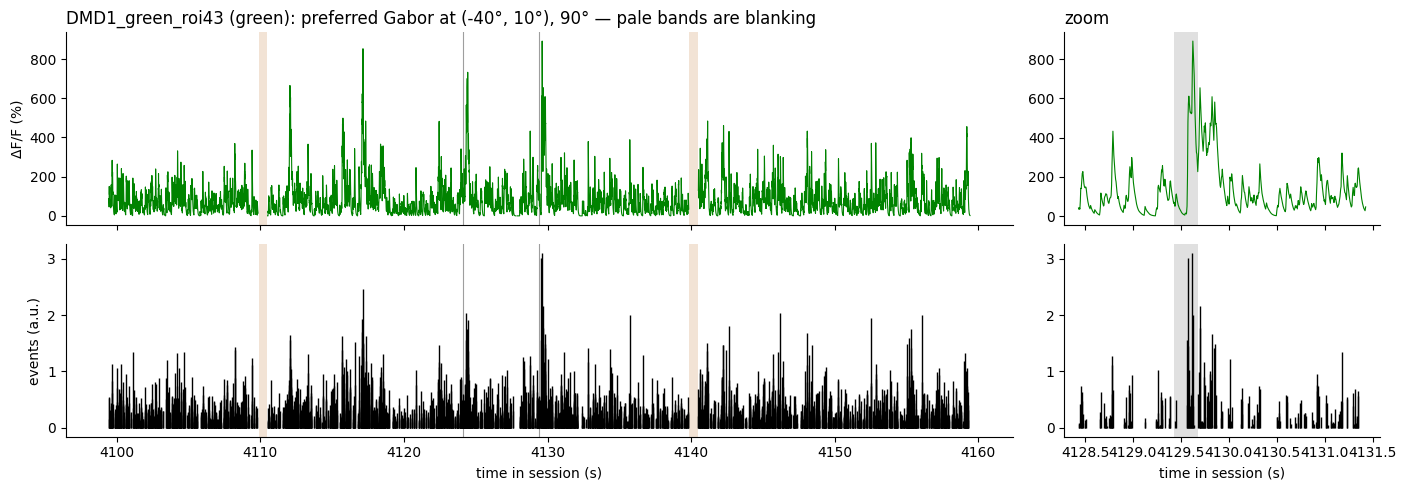

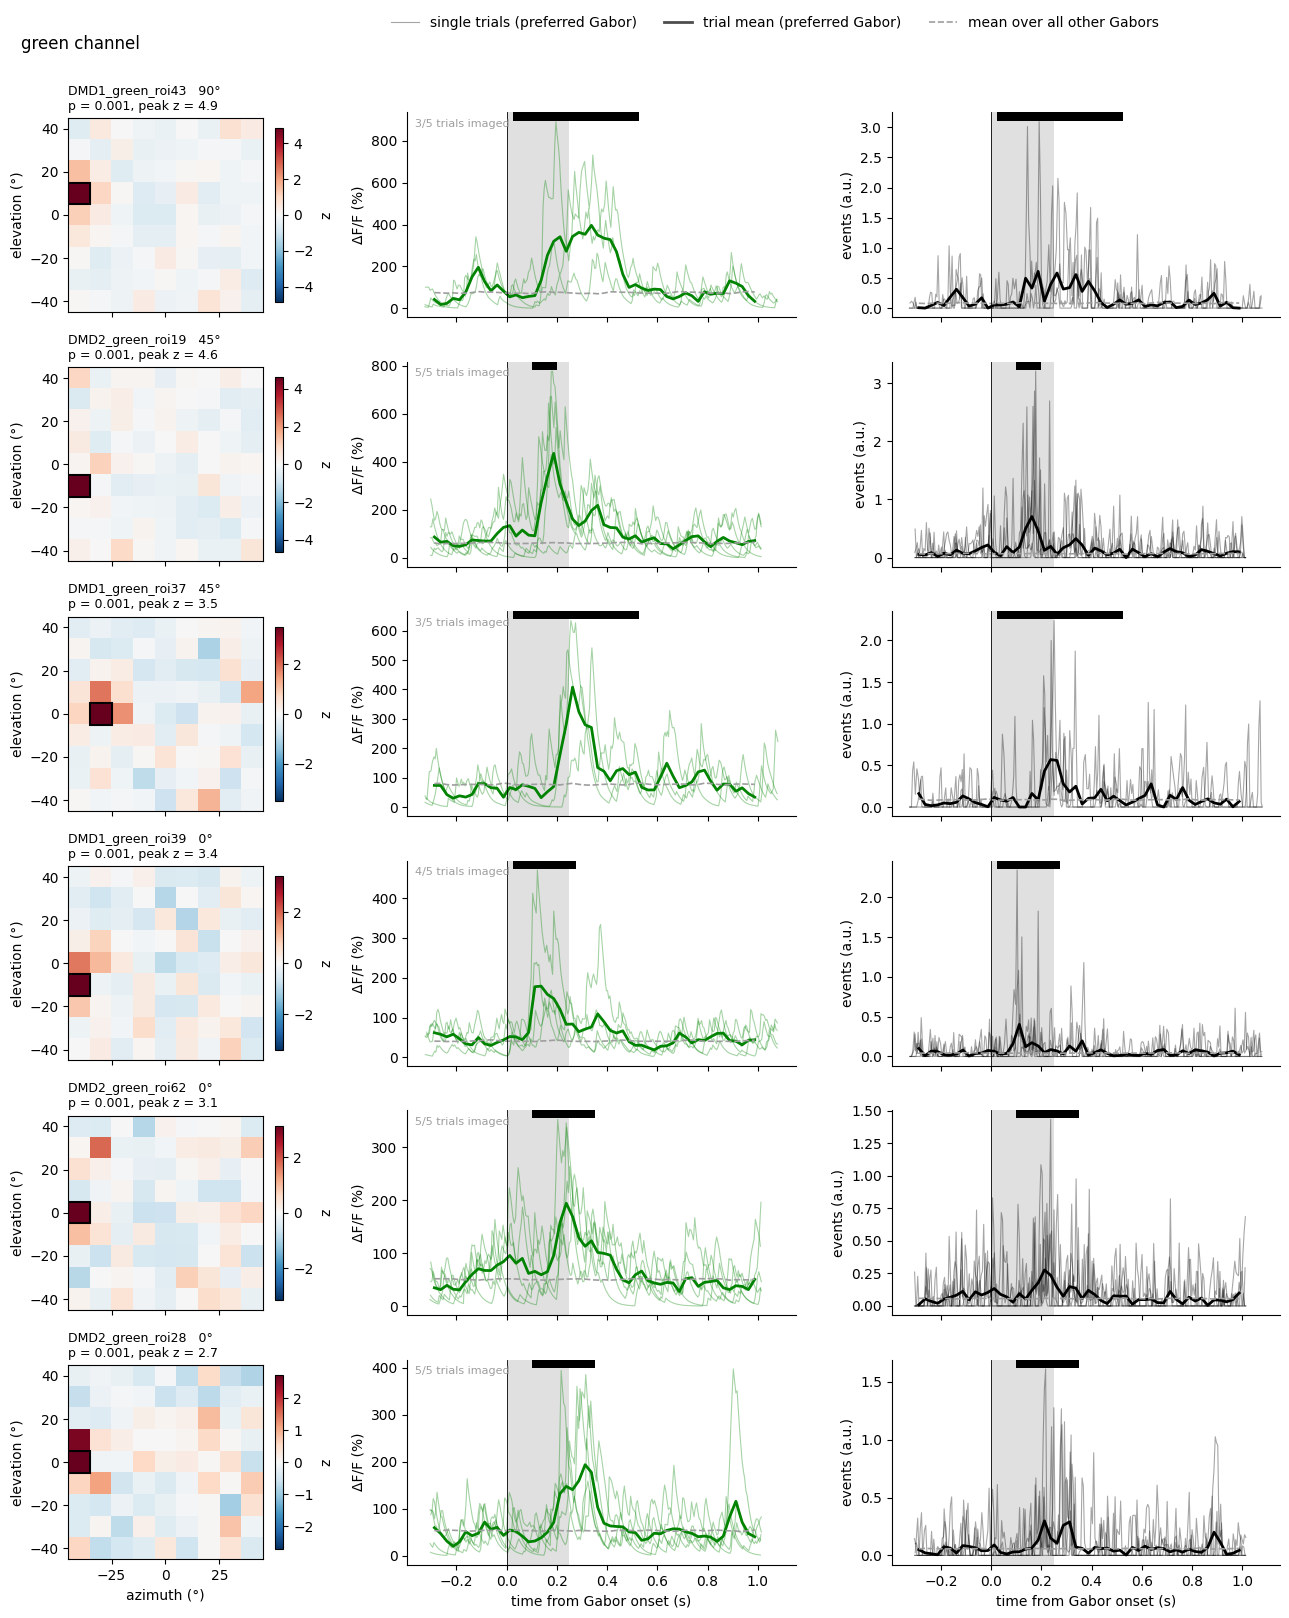

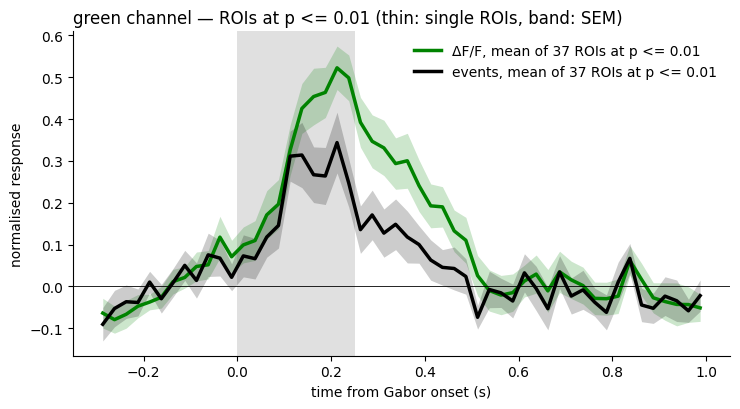

signal  n  grand_mean_peak_s  grand_mean_fwhm_s
   dff 37              0.213              0.275
events 37              0.213              0.150


peak_s        fwhm_s       
signal              dff events    dff events
unit_name                                   
DMD1_green_roi0   0.038  0.013  0.225  0.025
DMD1_green_roi10  0.738  0.638  0.125  0.025
DMD1_green_roi11  0.238  0.238  0.075  0.075
DMD1_green_roi17  0.413  0.413  0.050  0.050
DMD1_green_roi23  0.213  0.213  0.250  0.025
DMD1_green_roi29  0.113  0.438  0.075  0.025
DMD1_green_roi37  0.263  0.238  0.125  0.075
DMD1_green_roi39  0.138  0.113  0.125  0.025
DMD1_green_roi43  0.338  0.188  0.300  0.025
DMD1_green_roi45  0.213  0.188  0.075  0.025
DMD1_green_roi49  0.138  0.138  0.100  0.050
DMD1_green_roi5   0.313  0.288  0.050  0.025
DMD1_green_roi7  -0.037 -0.037  0.125  0.025
DMD1_green_roi9   0.063  0.213  0.325  0.025
DMD2_green_roi10  0.963  0.663  0.050  0.025
DMD2_green_roi12  0.188  0.163  0.075  0.050
DMD2_green_roi16  0.188  0.188  0.175  0.025
DMD2_green_roi19  0.188  0.163  0.075  0.075
DMD2_green_roi21  0.113 -0.237  0.075  0.025
DMD2_green_roi23  0.163  0.138  0.100  0.025
DMD2_green_roi25  0.513  0.488  0.075  0.025
DMD2_green_roi28  0.313  0.213  0.150  0.025
DMD2_green_roi40  0.213  0.213  0.100  0.025
DMD2_green_roi41  0.163  0.163  0.075  0.050
DMD2_green_roi42  0.313  0.213  0.200  0.025
DMD2_green_roi49  0.088  0.088  0.075  0.050
DMD2_green_roi50  0.138  0.113  0.100  0.050
DMD2_green_roi51  0.363  0.363  0.075  0.050
DMD2_green_roi54  0.213  0.213  0.100  0.050
DMD2_green_roi55  0.238  0.138  0.200  0.025
DMD2_green_roi57  0.163  0.113  0.050  0.050
DMD2_green_roi60  0.488  0.463  0.075  0.050
DMD2_green_roi62  0.238  0.213  0.100  0.075
DMD2_green_roi7  -0.037 -0.062  0.075  0.100
DMD2_green_roi70  0.163  0.338  0.075  0.025
DMD2_green_roi72  0.238  0.188  0.150  0.100
DMD2_green_roi73  0.188  0.363  0.100  0.025


==================== red ====================
red: 125 ROIs in 2 DMDs, 5 at the p-value floor (0.0010), 21 at p <= 0.01


,unit_name,p_value,z_peak,ori_deg,x,y,delay,duration
0,DMD2_red_roi16,0.000999,3.678430,0.0,-20.0,10.0,0.200,0.10
1,DMD1_red_roi27,0.000999,2.169335,45.0,-10.0,-40.0,0.025,0.25
2,DMD1_red_roi39,0.000999,2.146060,45.0,-40.0,-10.0,0.025,0.50
3,DMD1_red_roi36,0.000999,1.652233,0.0,40.0,-40.0,0.050,0.50
4,DMD1_red_roi43,0.000999,1.644755,45.0,40.0,-30.0,0.200,0.50
5,DMD1_red_roi46,0.001998,4.343998,0.0,10.0,40.0,0.200,0.10


  DMD1/red: 50 ROIs x 64505 samples over the RF block, 0.39 % of event samples blanked
  DMD2/red: 75 ROIs x 64505 samples over the RF block, 0.31 % of event samples blanked
DMD2_red_roi16: 5 of 5 preferred trials fully imaged


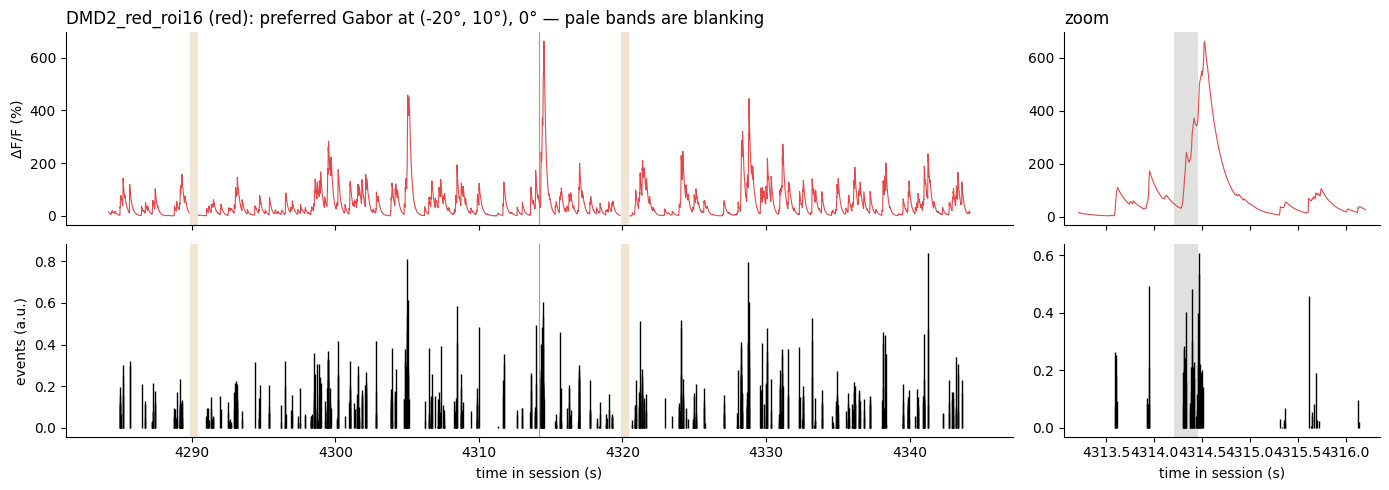

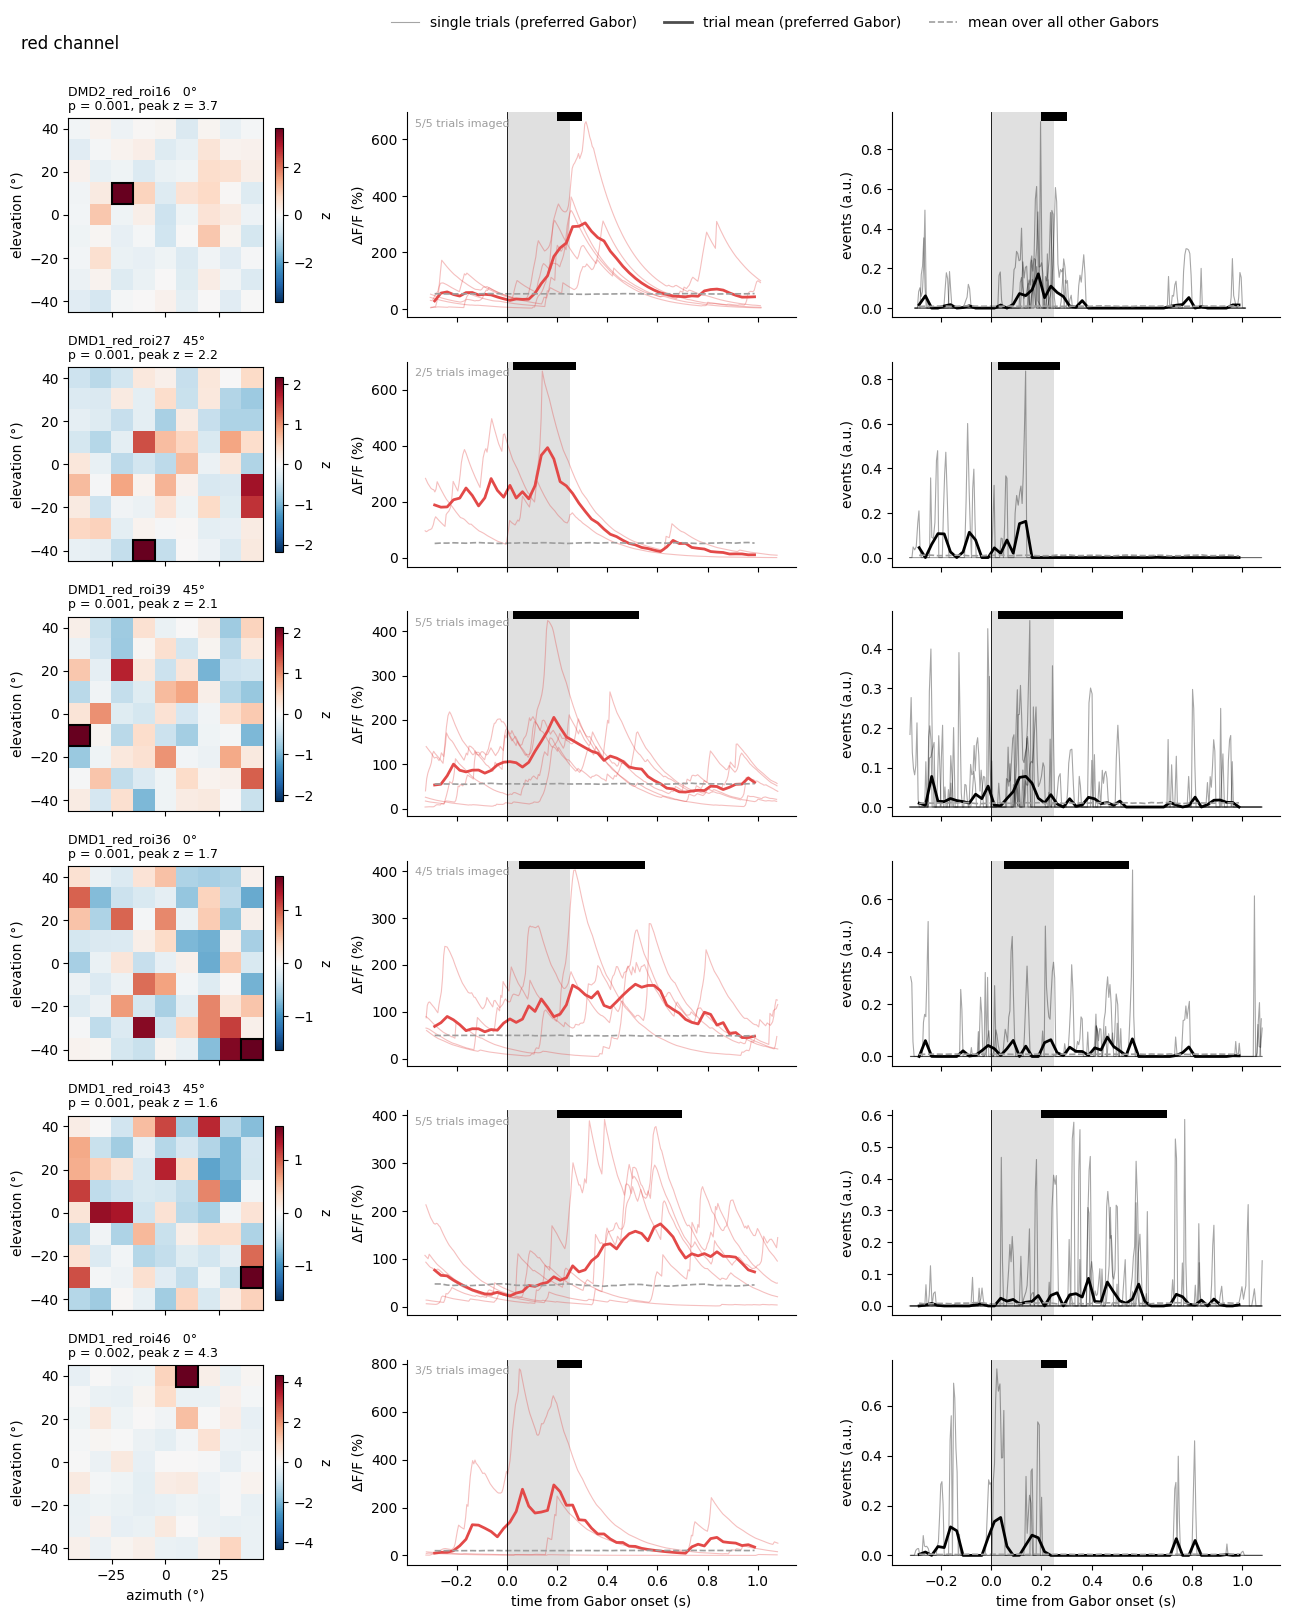

red: 1 of 21 ROIs at p <= 0.01 dropped from the timing summary (fewer than 3 imaged repeats)


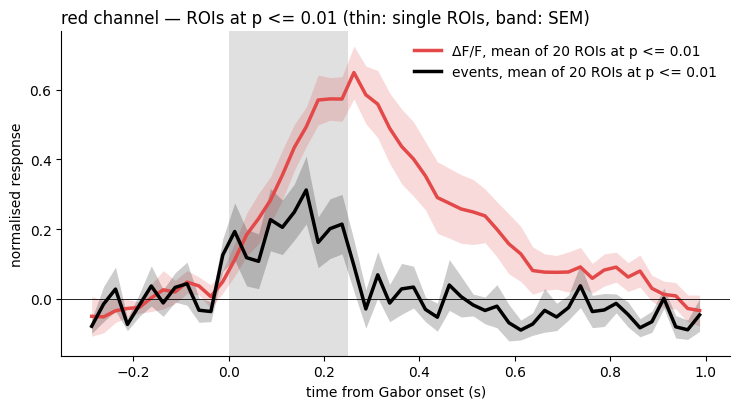

signal  n  grand_mean_peak_s  grand_mean_fwhm_s
   dff 20              0.263              0.325
events 20              0.163              0.175


peak_s        fwhm_s       
signal            dff events    dff events
unit_name                                 
DMD1_red_roi24  0.263  0.163  0.225  0.025
DMD1_red_roi29  0.188  0.088  0.225  0.025
DMD1_red_roi36  0.513  0.463  0.225  0.025
DMD1_red_roi37  0.263  0.263  0.125  0.075
DMD1_red_roi38  0.263  0.013  0.250  0.025
DMD1_red_roi39  0.188  0.138  0.175  0.075
DMD1_red_roi41  0.388  0.363  0.175  0.025
DMD1_red_roi43  0.613  0.388  0.325  0.025
DMD1_red_roi46  0.188  0.038  0.125  0.050
DMD1_red_roi6   0.263  0.238  0.200  0.025
DMD1_red_roi7  -0.137  0.663  0.075  0.025
DMD2_red_roi16  0.313  0.188  0.275  0.050
DMD2_red_roi19  0.188  0.163  0.175  0.050
DMD2_red_roi29  0.138  0.063  0.150  0.075
DMD2_red_roi5   0.313  0.213  0.325  0.025
DMD2_red_roi52  0.338  0.038  0.350  0.025
DMD2_red_roi62  0.138  0.113  0.200  0.025
DMD2_red_roi64  0.088  0.063  0.175  0.025
DMD2_red_roi72  0.213  0.138  0.200  0.050
DMD2_red_roi9   0.213  0.088  0.300  0.025

In [57]:
per_channel = {}
for channel in CHANNELS:
    print(f'\n{"=" * 20} {channel} {"=" * 20}')
    units = load_units(channel)
    examples = pick_examples(units)
    display(examples[['unit_name', 'p_value', 'z_peak', 'ori_deg', 'x', 'y', 'delay', 'duration']])

    # both DMDs, so the population panel below can use every ROI at the floor
    traces = load_traces(channel, stream.dmds())
    plot_block(examples.iloc[0], traces, channel)
    plot_aligned(examples, traces, channel)

    selected = units[units['selected']].reset_index(drop=True)
    timing = plot_timing(selected, traces, channel, what=f'ROIs at p <= {P_MAX}')
    display(timing)

    per_channel[channel] = {'units': units, 'examples': examples,
                            'traces': traces, 'selected': selected, 'timing': timing}

## The kinetics the deconvolution fitted

`utils.deconvolution` estimates one decay time per ROI and stores it in the
cache, so the two sensors can be compared directly. Green is a glutamate sensor
and red a calcium sensor, so green should come out several times faster; if it
does not, something about the fit is wrong.

DMD1 green: median tau 39 ms (36–47 ms), n = 50
DMD1 red: median tau 259 ms (236–272 ms), n = 50


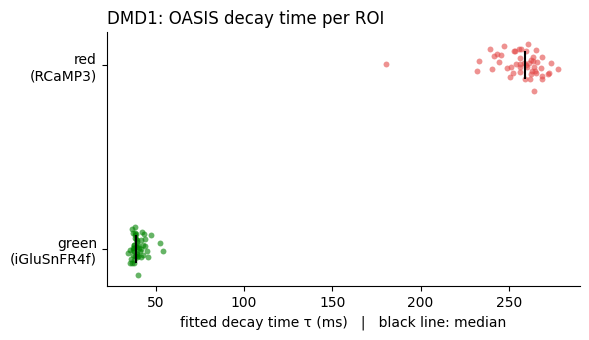

In [55]:
dmd = per_channel[CHANNELS[0]]['examples']['dmd'].iloc[0]

fig, ax = plt.subplots(figsize=(6, 3.5))
labels = []
for i, channel in enumerate(CHANNELS):
    with h5py.File(events_path(NWB_PATH, dmd, channel)) as hf:
        tau = 1000 * hf['tau_hat'][:]
    tau = tau[np.isfinite(tau)]
    jitter = np.random.default_rng(0).normal(0, 0.06, len(tau))
    ax.scatter(tau, np.full(len(tau), i) + jitter, s=18, alpha=0.6,
               color=CHANNEL_COLORS[channel], lw=0)
    ax.scatter(np.median(tau), i, marker='|', s=400, color='k', zorder=3)
    labels.append(f'{channel}\n({"iGluSnFR4f" if channel == "green" else "RCaMP3"})')
    print(f'{dmd} {channel}: median tau {np.median(tau):.0f} ms '
          f'({np.percentile(tau, 5):.0f}–{np.percentile(tau, 95):.0f} ms), n = {len(tau)}')

ax.set_yticks(range(len(CHANNELS)), labels)
ax.set_xlabel('fitted decay time τ (ms)   |   black line: median')
ax.set_title(f'{dmd}: OASIS decay time per ROI', loc='left')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
plt.show()

## What this shows

Written for the ROIs picked above from sub-829704; rerun before trusting the
numbers for another session.

* **Green barely needs it.** iGluSnFR4f decays in tens of milliseconds, so its
  ΔF/F already resolves a single 0.25 s Gabor. Over the 37 green ROIs at
  p ≤ 0.01 the grand mean narrows from 0.275 s FWHM (ΔF/F) to 0.150 s (events)
  while peaking at the same time (0.213 s), and both signals are back at
  baseline by ~0.45 s.
* **Red is the case deconvolution is for.** RCaMP3's fitted decay is ~260 ms —
  about one inter-stimulus interval — so in ΔF/F each response runs into the
  following presentations. Over the 20 red ROIs at p ≤ 0.01 the ΔF/F grand mean
  is 0.325 s wide and still visibly elevated past 0.5 s, while the events are
  0.175 s wide and peak 0.10 s earlier (0.163 s against 0.263 s).
* **The baseline differs in both channels.** Events are non-negative and near
  zero between transients, so the mean over all other Gabors sits at
  essentially zero, while ΔF/F keeps an offset from preceding responses.
* **Blanking costs trials, not much.** With 12 bouts covering this RF block
  almost completely, most Gabors keep 4 or 5 of their 5 repeats; the count is
  shown per ROI, and ROIs below 3 are left out of the timing summary — 1 of the
  21 red ROIs is dropped that way.
* **Where the population comes from.** Only 9 of 125 green and 5 of 125 red ROIs
  reach the permutation floor, against more than half of the mesoscope ROIs, so
  the panels use p ≤ 0.01 (37 green, 20 red). These p-values take the minimum
  over 3 orientations and 15 delay × duration cells with no multiple-comparison
  correction, so they are biased low; the threshold selects ROIs worth averaging,
  it does not certify each one. Raise or lower `P_MAX` to trade population size
  against how strongly driven the members are.
* **The fitted decay times separate the two sensors by roughly a factor of
  five**, which is the main evidence that the per-ROI parameter estimation is
  doing something sensible on SLAP2 data.